# Unsupervised learning. Clustering

## 1.Answers

The method that I used for my k-means realisation is initializing the centroids coordinates, by choosing random values for each dimension between the borderline values for this dimension. This method is really fast and works well if we suppose that data is distributed equally in this space, but it also doesn't always converge to the global minimum and can show bad results if there is a lot of noise.  

Other well-known methods for initialisation include Forgy and Random Partition. The big andvantages of Forgy are that it is really fast, and since we expect this points to be near the clusters, it can give us a pretty nice distribution, the biggest disadvantage though is that more than one dot from the cluster can be chosen as the centroid, making it harder for the algorithm to converge. Random partition on the other hand doesn't have this issue, since the centroids it initialises are located close to the global mean of the data, though it can also lead to problems, since the algorithm can get stuck on the local optimum.

To speed up the KNN, we can use either kd-tree or centroids. To use the centroid based approach, you need to cluster data using kmeans, then with the test data, you find the closest centroids, where from their points you can run knn, significantly speeding up the process, though this approach can reduce accuracy of your predictions. KD-tree approach is on the other hand based on building k-dimensions tree, which if k = 1 is binary search tree, and as so the algorithm will go through all the branches, where the distance between the dot and the splitting plane is less than the current distance, in the context of knn you should use the priority queue for the k best candidates. This approach is accurate, though it can be slower than the centroid one if k > m (number of the chosen centroids).  

## 2.Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import KDTree

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_percentage_error
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import Lasso
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_json("data/train.json")
lower_thr, upper_thr = data["price"].quantile(0.01), data["price"].quantile(0.99)
data = data[(data["price"] > lower_thr) & (data["price"] < upper_thr)]

In [ ]:
feature_list = ['Elevator', 'Hardwood Floors', 'Cats Allowed', 'Dogs Allowed', 'Doorman', 'Dishwasher', 'No Fee', 'Laundry in Building', 'Fitness Center', 'Pre-War', 'Laundry in Unit', 'Roof Deck', 'Outdoor Space', 'Dining Room', 'High Speed Internet', 'Balcony', 'Swimming Pool', 'Laundry In Building', 'New Construction', 'Terrace']
feat = data.apply(lambda row: [1 if feat in row['features'] else 0 for feat in feature_list], axis=1).tolist()
feat = pd.DataFrame(feat, columns=feature_list, index=data.index)

In [ ]:
interes_level_dict = {'low':0, 'medium':0.5, 'high':1}
interest_level = data["interest_level"].apply(lambda elem: interes_level_dict[elem])
feat = pd.concat([feat, interest_level], axis=1, join='inner')

In [ ]:
feat = pd.concat([feat, data["bathrooms"], data["bedrooms"], data["latitude"], data["longitude"], data["price"]], axis=1)

In [ ]:
scaler = MinMaxScaler()
feat_unscl = feat
feat = pd.DataFrame(scaler.fit_transform(feat), columns=feat.columns)

In [ ]:
print(feat.shape)

(48343, 26)


In [ ]:
feat_train, feat_test = train_test_split(feat, test_size=0.3, random_state=21)
feat_train_unscl = feat_unscl.iloc[feat_train.index].reset_index(drop=True)
feat_train = feat_train.reset_index(drop=True)
feat_test = feat_test.reset_index(drop=True)

In [ ]:
feat_train.head()

,Elevator,Hardwood Floors,Cats Allowed,Dogs Allowed,Doorman,Dishwasher,No Fee,Laundry in Building,Fitness Center,Pre-War,...,Swimming Pool,Laundry In Building,New Construction,Terrace,interest_level,bathrooms,bedrooms,latitude,longitude,price
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.1,0.000,0.947561,0.374713,0.009991
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.1,0.000,0.947231,0.374448,0.079496
2,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.5,0.1,0.125,0.947621,0.374771,0.143788
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.1,0.000,0.948165,0.374772,0.023023
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.1,0.125,0.947665,0.374723,0.096438


In [ ]:
def distortion(X, y, centers):
    X = np.asarray(X)
    y = np.asarray(y)
    centers = np.asarray(centers)
    tot_sum = 0
    for i in range(len(centers)):
        sel = X[y == i]
        half_sums = [((dot - centers[i]) ** 2).sum() for dot in sel]
        tot_sum += sum(half_sums)
    return tot_sum / len(y)

In [ ]:
def pipeline(pred, feat, title, lasso_pars={"alpha":0.00001}, centers=None):
    feat = feat.reset_index()
    print("Sillhouette score:", silhouette_score(feat[["longitude", "latitude"]], pred), "\n")
    if centers is not None:
        print("Distortion score:", distortion(feat[["longitude", "latitude"]], pred, centers), "\n")

    res = pd.concat([feat[["longitude", "latitude"]], pd.Series(pred, name="pred")], axis=1)
    res = res[(res['latitude'] >= 0.943) & (res['latitude'] <= 0.951) & (res['longitude'] >= 0.374) & (res['longitude'] <= 0.376)]

    plt.figure(figsize=(12, 12))
    plt.scatter(res["longitude"], res["latitude"], c=res["pred"], s=50, alpha=0.7)
    plt.title(title)
    plt.xlabel('longitude')
    plt.ylabel('latitude')
    plt.grid(True, alpha=0.3)
    plt.show()
    print("\n")

    scaler = MinMaxScaler()
    pred_scl = scaler.fit_transform(pred.reshape(-1, 1))
    feat = pd.concat([feat, pd.Series(pred_scl.reshape(1, -1)[0], name="cluster")], axis=1)

    lasso = Lasso()
    lasso.set_params(**lasso_pars)
    lasso.fit(feat.drop("price", axis=1), feat["price"])
    print("R2 score:", r2_score(feat["price"], lasso.predict(feat.drop("price", axis=1))), "\n")
    feat = feat.drop("cluster", axis=1)

    weights = pd.DataFrame(np.abs(lasso.coef_), index=lasso.feature_names_in_, columns=["weight"])
    print(weights.sort_values(by="weight", ascending=False).head(10))

## 3.K-means

In [ ]:
class Kmeans():
    def __init__(self, k, max_steps=100, random_state=21):
        self.k = k
        self.max_steps = max_steps
        self.random_state = random_state

        self.centers = None

    def fit(self, X):
        np.random.seed(self.random_state)
        X = np.asarray(X)

        centers = []
        for i in range(self.k):
            centroid = []
            for feat in range(X.shape[1]):
                feat_max, feat_min, feat_av = X[:, feat].max(), X[:, feat].min(), np.mean(X[:, feat])
                elem = ((feat_max - feat_min) * np.random.rand() + feat_min + feat_av) / 2
                centroid.append(elem)
            centers.append(centroid)

        centers = np.array(centers)
        clusters = self.calculate_clusters(centers, X)

        for step in range(self.max_steps):
            for i in range(self.k):
                clust = [X[ind] for ind in clusters[i]]

                if len(clust) > 1:
                    centers[i] = np.mean(clust)

            clusters = self.calculate_clusters(centers, X)

        self.centers = centers

    def calculate_clusters(self, centers, X):
        clusters = [[] for m in range(self.k)]
        for ind in range(len(X)):
            dot = X[ind]

            minim = (0, np.inf)
            for i in range(len(centers)):
                distance = np.linalg.norm(dot - centers[i])
                if distance < minim[1]:
                    minim = (i, distance)

            clusters[minim[0]].append(ind)

        return clusters

    def predict(self, X):
        if self.centers is None:
            raise Exception("Model is not fit")
        X = np.asarray(X)

        clusters = self.calculate_clusters(self.centers, X)

        y = np.zeros(len(X))
        for i in range(self.k):
            for ind in clusters[i]:
                y[ind] = i

        return y


In [ ]:
%%time
kmeans = Kmeans(k=30)
kmeans.fit(feat_train[["longitude", "latitude"]])
kmeans_pred = kmeans.predict(feat_train[["longitude", "latitude"]])

CPU times: user 10min 54s, sys: 915 ms, total: 10min 55s
Wall time: 11min 3s


Sillhouette score: 0.20337658411719287 

Distortion score: 0.1638962922096211 



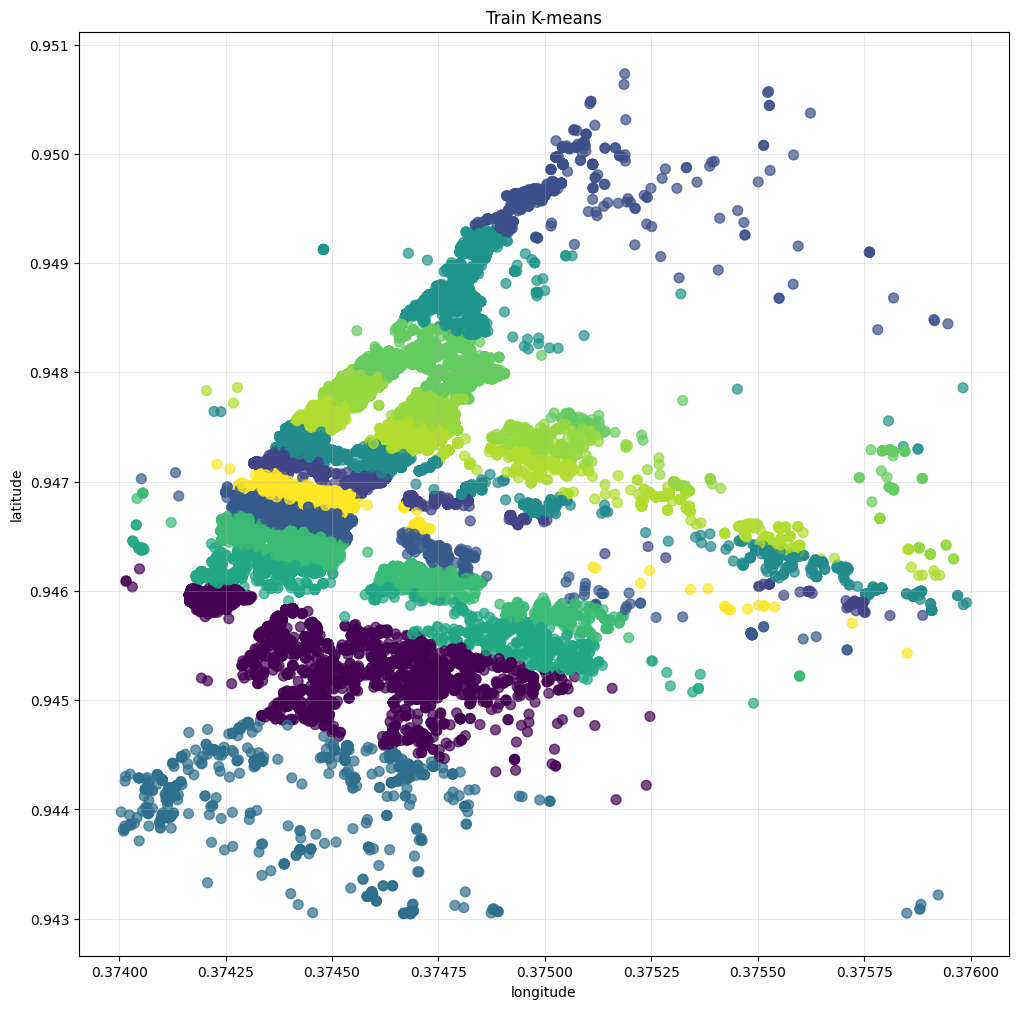



R2 score: 0.606920192123211 

                       weight
bathrooms            1.287403
bedrooms             0.335146
interest_level       0.072432
Doorman              0.048686
Laundry in Unit      0.038288
cluster              0.021178
Fitness Center       0.020058
Elevator             0.019399
Laundry in Building  0.017355
Laundry In Building  0.016924


In [ ]:
pipeline(kmeans_pred, feat_train, "Train K-means", centers=kmeans.centers)

In [ ]:
%%time
skmeans = KMeans(n_clusters=30, random_state=21)
skmeans_pred = skmeans.fit_predict(feat_train[["longitude", "latitude"]])

CPU times: user 248 ms, sys: 11.8 ms, total: 260 ms
Wall time: 172 ms


Sillhouette score: 0.44012303091143695 

Distortion score: 2.6402398504793935e-08 



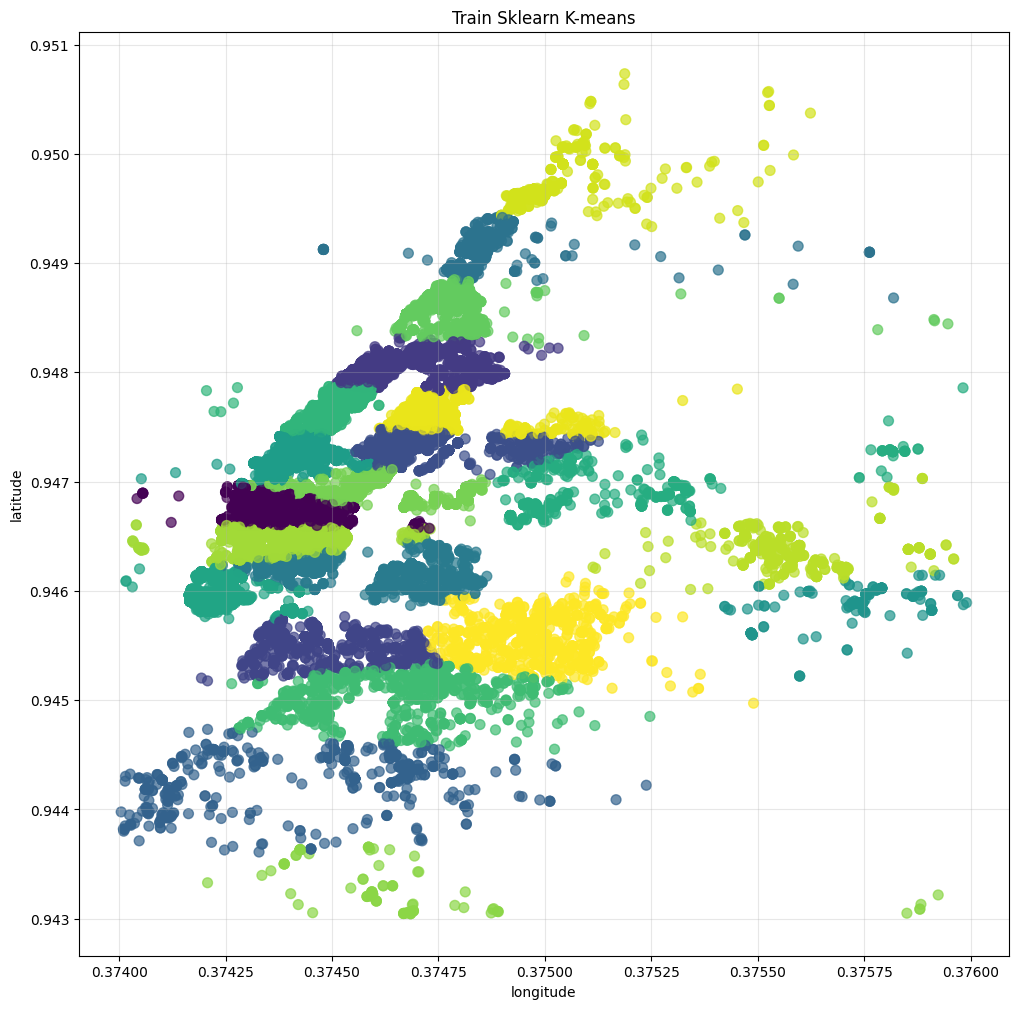



R2 score: 0.6075151060399124 

                       weight
bathrooms            1.296060
bedrooms             0.332302
interest_level       0.072688
Doorman              0.048724
Laundry in Unit      0.037198
longitude            0.025525
cluster              0.021934
Elevator             0.018590
Laundry In Building  0.017808
Fitness Center       0.017400


In [ ]:
pipeline(skmeans_pred, feat_train, "Train Sklearn K-means", centers=skmeans.cluster_centers_)

## 4.DBScan

In [ ]:
class DBScan():
    def __init__(self, minPts, eps):
        self.minPts = minPts
        self.eps = eps

    def fit_predict(self, X):
        X = np.asarray(X)
        classes = np.zeros(len(X))
        inds = np.array([i for i in range(len(X))])

        clust = 0
        for i, dot in enumerate(X):
            if classes[i] != 0:
                continue

            neigh = self.neighbours(dot, X, inds, i)
            if len(neigh) + 1 < self.minPts:
                classes[i] = -1
                continue

            clust += 1
            classes[i] = clust
            sdot = 0
            while sdot < len(neigh):
                sind = int(neigh[sdot][0])
                sdotdot = neigh[sdot][1]
                sdot += 1
                if classes[sind] == -1:
                    classes[sind] = clust
                if classes[sind] != 0:
                    continue
                classes[sind] = clust

                sneigh = self.neighbours(sdotdot, X, inds, sind)
                if len(sneigh) + 1 >= self.minPts:
                    neigh = np.vstack([neigh, sneigh])

        return classes

    def neighbours(self, dot, X, inds, self_ind):
        dists = np.sqrt(np.sum((X - dot)**2, axis=1))
        mask = dists <= self.eps
        dists = dists[mask]
        inds = inds[mask]
        return np.array([[inds[i], dists[i]] for i in range(len(inds)) if inds[i] != self_ind])

In [ ]:
%%time
dbscan = DBScan(10, 0.001)
dbscan_pred = dbscan.fit_predict(feat_train_unscl[["longitude", "latitude"]])

CPU times: user 18.4 s, sys: 37.8 ms, total: 18.4 s
Wall time: 20.3 s


Sillhouette score: 0.31754862688712543 



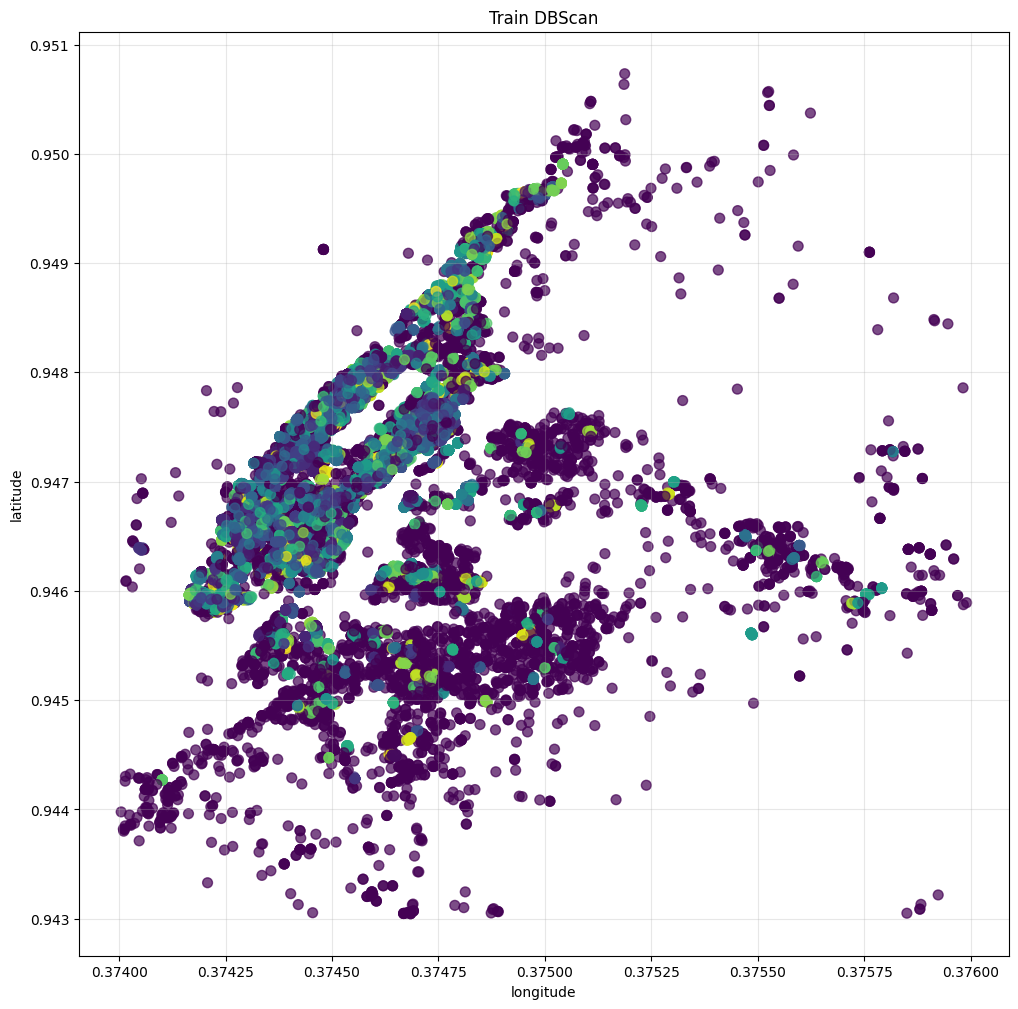



R2 score: 0.6084192784585323 

                       weight
bathrooms            1.289118
bedrooms             0.333149
interest_level       0.072582
Doorman              0.050121
Laundry in Unit      0.037022
cluster              0.034728
Laundry In Building  0.018371
Fitness Center       0.018074
Elevator             0.017840
High Speed Internet  0.016607


In [ ]:
pipeline(dbscan_pred, feat_train, "Train DBScan")

In [ ]:
%%time
skdbscan = DBSCAN(eps=0.001, min_samples=10)
skdbscan_pred = skdbscan.fit_predict(feat_train_unscl[["longitude", "latitude"]])

CPU times: user 798 ms, sys: 936 µs, total: 799 ms
Wall time: 1.43 s


Sillhouette score: -0.20860199878689506 



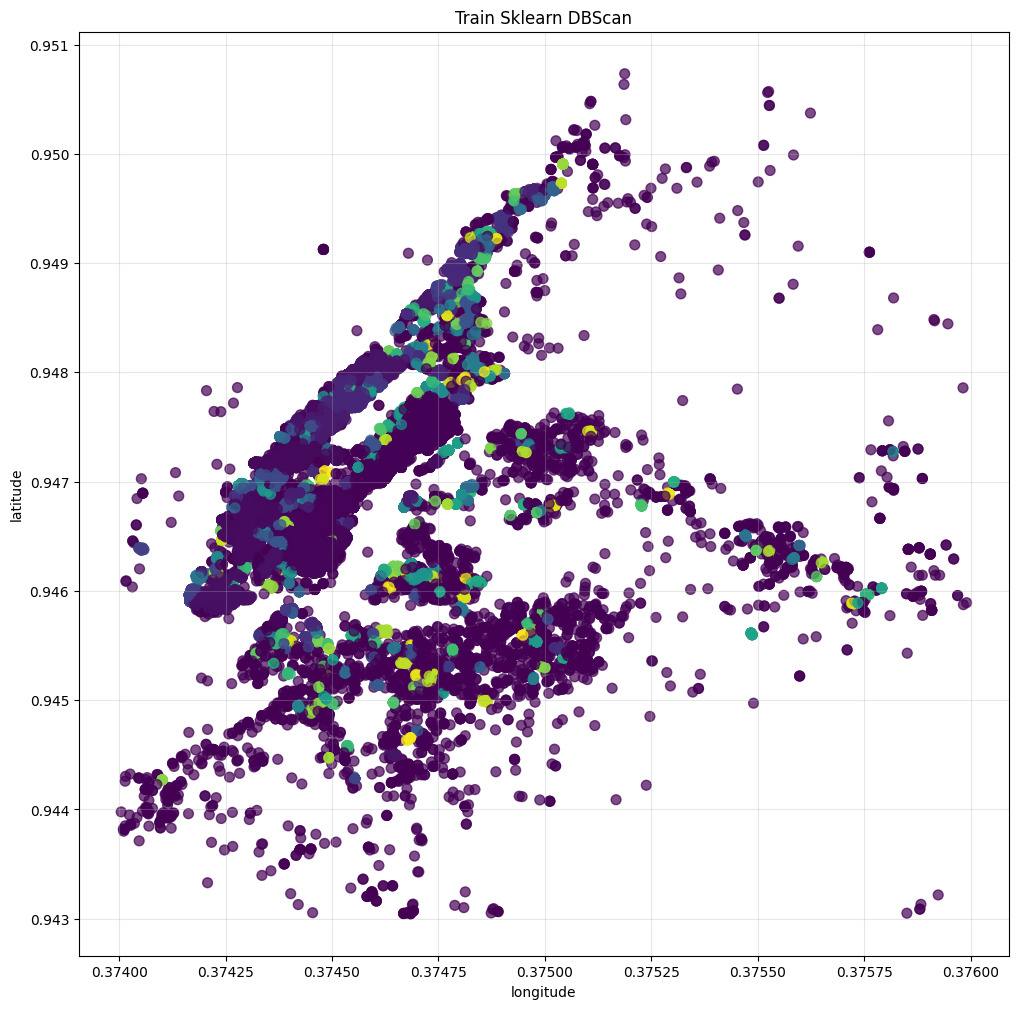



R2 score: 0.6075514881199404 

                       weight
bathrooms            1.292755
bedrooms             0.333933
interest_level       0.073118
Doorman              0.047727
Laundry in Unit      0.038659
cluster              0.038089
Elevator             0.019496
Laundry In Building  0.019194
Fitness Center       0.018233
Laundry in Building  0.017348


In [ ]:
pipeline(skdbscan_pred, feat_train, "Train Sklearn DBScan")

## 5.Agglomerative Clustering

In [ ]:
class AgglomeratClust():
    def __init__(self, k):
        self.k = k
        if k < 2:
            raise Exception("Useless k value")

    def fit_predict(self, X):
        X = np.asarray(X)
        clusts = [[i] for i in range(len(X))]
        dots = X

        while len(clusts) > self.k:
            dist, dot_inds = self.dists(dots)
            sec_clust = clusts.pop(dot_inds[1])
            sec = dots[dot_inds[1]]
            dots = np.delete(dots, dot_inds[1], axis=0)
            first = dots[dot_inds[0]]
            len_clusts = (len(clusts[dot_inds[0]]), len(sec_clust))
            clusts[dot_inds[0]] += sec_clust

            dots[dot_inds[0]] = (first * len_clusts[0] + sec * len_clusts[1]) / sum(len_clusts)

        res = np.zeros(len(X))
        for i, inds in enumerate(clusts):
            res[inds] = i

        return res

    def dists(self, dots):
        tree = KDTree(dots)
        dist, id = tree.query(dots, k=2)
        min_id = np.argmin(dist[:, 1])

        return dist[min_id, 1], (min_id, id[min_id, 1])

In [ ]:
%%time
agglo_clust = AgglomeratClust(k=30)
agglo_clust_pred = agglo_clust.fit_predict(feat_train_unscl[["longitude", "latitude"]])

CPU times: user 34min 55s, sys: 1.64 s, total: 34min 57s
Wall time: 35min 26s


Sillhouette score: 0.28519246905539747 



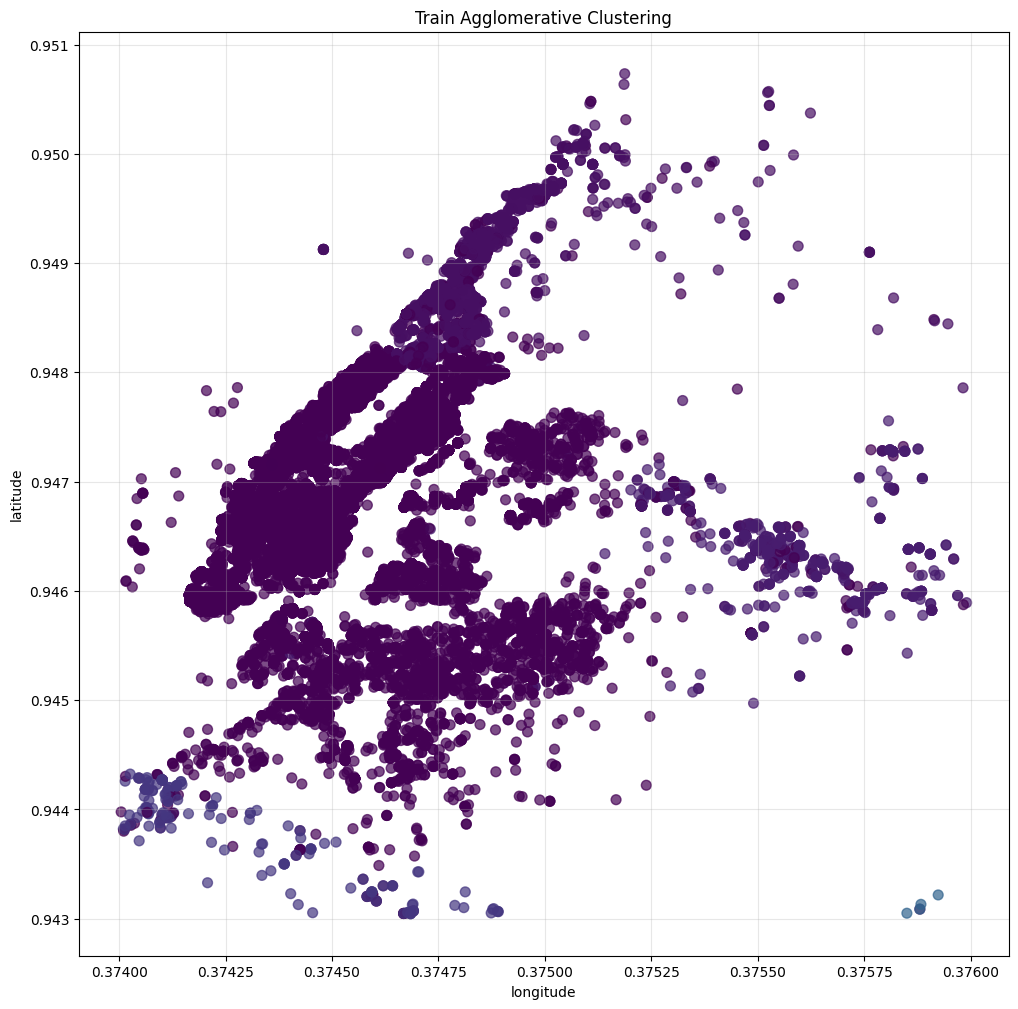



R2 score: 0.6132103912628979 

                       weight
bathrooms            1.294478
cluster              0.520243
bedrooms             0.335568
interest_level       0.071918
Doorman              0.046340
Laundry in Unit      0.037712
latitude             0.030569
Elevator             0.020069
Laundry In Building  0.018512
Fitness Center       0.018094


In [ ]:
pipeline(agglo_clust_pred, feat_train, "Train Agglomerative Clustering")

In [ ]:
agglo_feat_train = feat_train_unscl[["longitude", "latitude"]].astype("float16")
agglo_feat_train = agglo_feat_train.reset_index(drop=True)
sample = agglo_feat_train.sample(frac=0.5, random_state=21)
sample = sample.sort_index(ascending=True)

In [ ]:
%%time
sk_agglo_clust = AgglomerativeClustering(n_clusters=30, compute_full_tree=False, linkage="average")
sk_agglo_clust_pred = sk_agglo_clust.fit_predict(sample)

CPU times: user 29.6 s, sys: 2.87 s, total: 32.5 s
Wall time: 38 s


Sillhouette score: 0.06204711810156412 



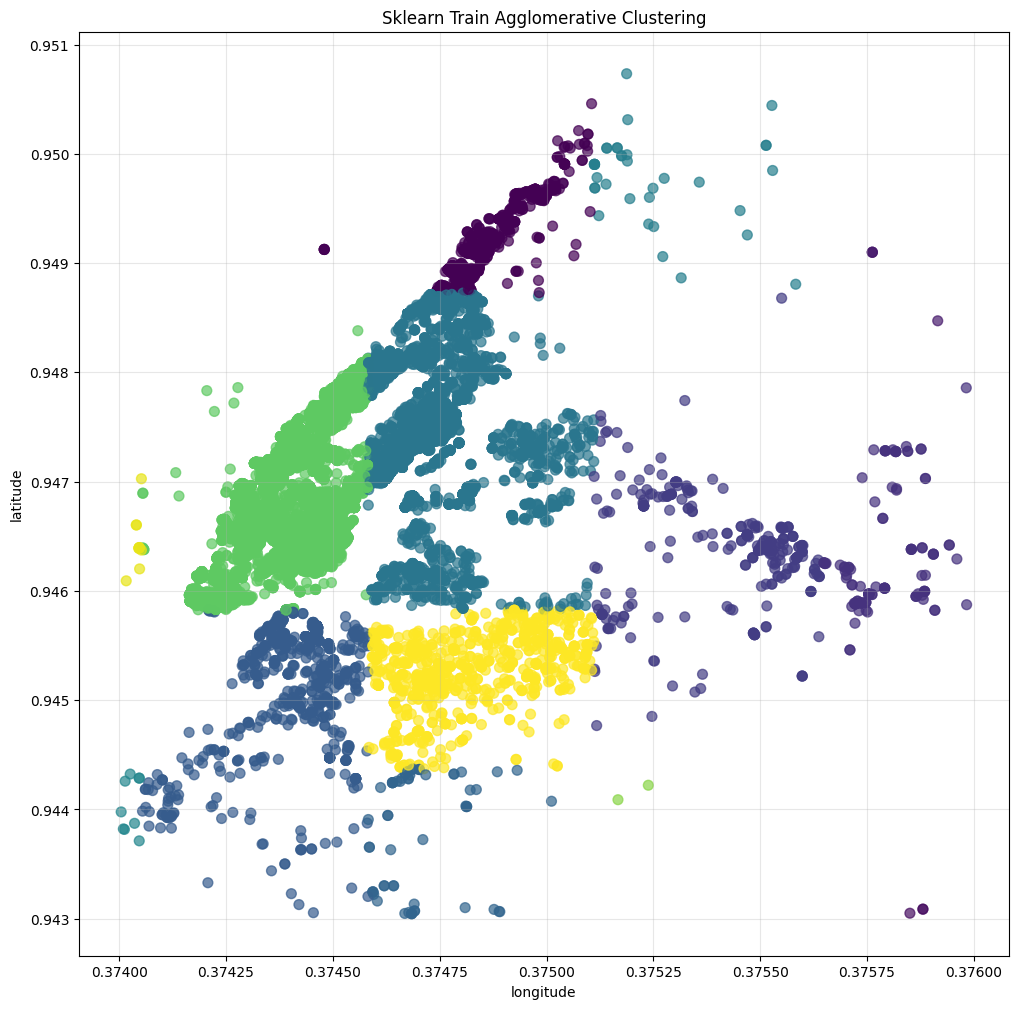



R2 score: 0.6307699344592499 

                       weight
bathrooms            1.310722
bedrooms             0.331404
cluster              0.098892
interest_level       0.071039
Doorman              0.041640
Laundry in Unit      0.036452
Laundry In Building  0.022977
Elevator             0.020149
High Speed Internet  0.016356
Laundry in Building  0.015963


In [ ]:
inds = sample.index
pipeline(sk_agglo_clust_pred, feat_train.iloc[inds], "Sklearn Train Agglomerative Clustering")

## 6.Gaussian Mixture

In [ ]:
%%time
skgauss_mixt = GaussianMixture(n_components=30)
skgauss_mixt_pred = skgauss_mixt.fit_predict(feat_train_unscl[["longitude", "latitude"]])

CPU times: user 7.01 s, sys: 330 ms, total: 7.34 s
Wall time: 4.65 s


Sillhouette score: 0.3371817893423615 



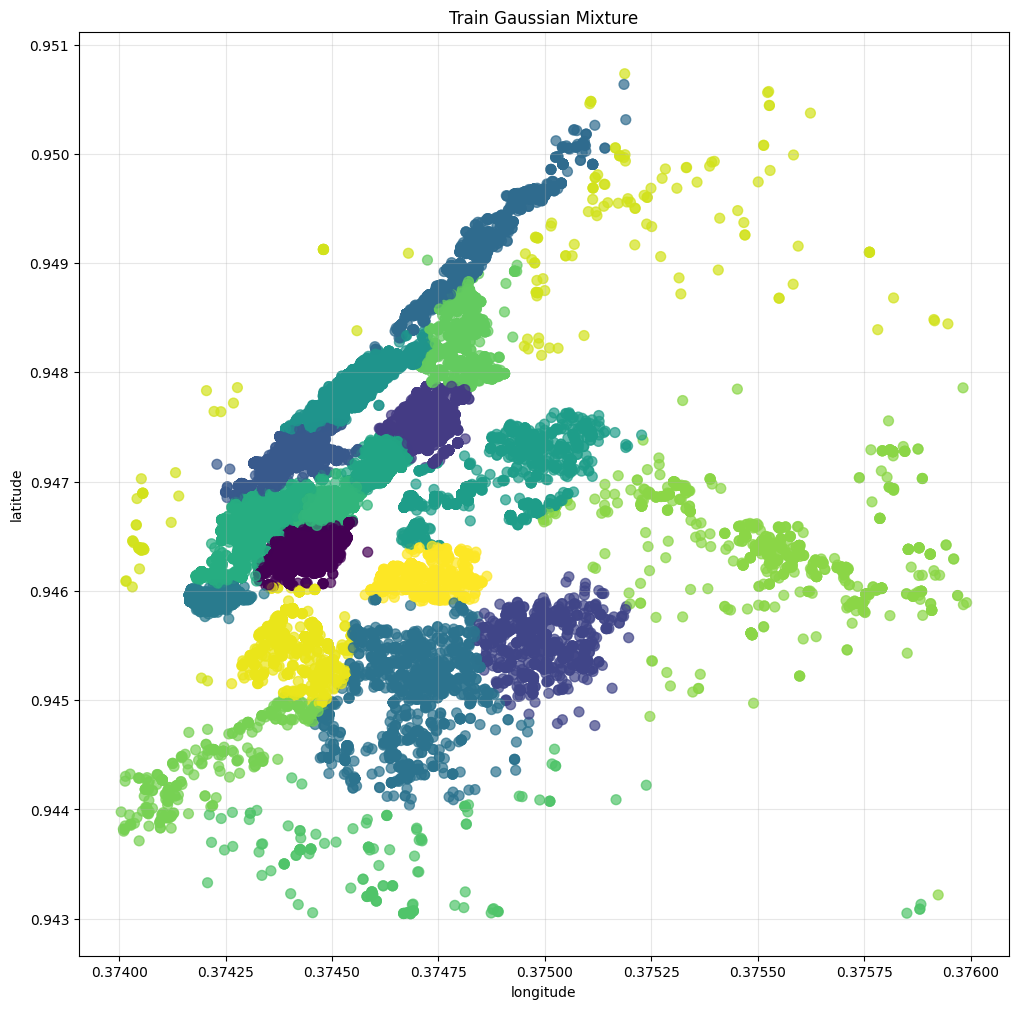



R2 score: 0.6054193371899221 

                       weight
bathrooms            1.297185
bedrooms             0.332312
interest_level       0.072737
Doorman              0.048738
Laundry in Unit      0.037943
Elevator             0.019245
Fitness Center       0.018352
Laundry In Building  0.018247
Laundry in Building  0.016948
longitude            0.016398


In [ ]:
pipeline(skgauss_mixt_pred, feat_train, "Train Gaussian Mixture")

## 7.Comparison

In [ ]:
def pipeline_2(pred, feat, model, features, pred_test=None, feat_test=None):
    print("Sillhouette score:", silhouette_score(feat[features], pred))

    scaler = MinMaxScaler()
    pred_scl = scaler.fit_transform(pred.reshape(-1, 1))
    feat = pd.concat([feat, pd.Series(pred_scl.reshape(1, -1)[0], name="cluster")], axis=1)

    X_train, y_train = feat.drop("price", axis=1), feat["price"]

    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)

    print(f"R2 Train score: {r2_score(y_train, y_train_pred)}")

    if pred_test is not None and feat_test is not None:
        pred_scl = scaler.fit_transform(pred_test.reshape(-1, 1))
        feat_test = pd.concat([feat_test, pd.Series(pred_scl.reshape(1, -1)[0], name="cluster")], axis=1)

        X_test, y_test = feat_test.drop("price", axis=1), feat_test["price"]
        y_test_pred = model.predict(X_test)

        print(f"R2 Test score: {r2_score(y_test, y_test_pred)}")

In [ ]:
features = ["bedrooms", "bathrooms", "interest_level"]

In [ ]:
lasso = Lasso(alpha=0.00001)

In [ ]:
%%time
test_kmeans = KMeans(n_clusters=28, random_state=21)
test_kmeans_train_pred = test_kmeans.fit_predict(feat_train[features])
test_kmeans_test_pred = test_kmeans.predict(feat_test[features])

CPU times: user 80.4 ms, sys: 2.27 ms, total: 82.7 ms
Wall time: 48.9 ms


In [ ]:
pipeline_2(test_kmeans_train_pred, feat_train, lasso, features, test_kmeans_test_pred, feat_test)

Sillhouette score: 0.9599412077176724
R2 Train score: 0.6067893569752738
R2 Test score: 0.6160806601877606


In [ ]:
%%time
test_dbscan = DBSCAN(eps=0.05, min_samples=10, algorithm="kd_tree")
test_dbscan_pred = test_dbscan.fit_predict(feat_train[features])

CPU times: user 1.98 s, sys: 3.9 s, total: 5.88 s
Wall time: 5.98 s


In [ ]:
pipeline_2(test_dbscan_pred, feat_train, lasso, features)

Sillhouette score: 0.971592000114548
R2 Train score: 0.6075038835287476


In [ ]:
%%time
test_gauss_mixt = GaussianMixture(n_components=28)
test_gauss_mixt_train_pred = test_gauss_mixt.fit_predict(feat_train[features])
test_gauss_mixt_test_pred = test_gauss_mixt.fit_predict(feat_test[features])

CPU times: user 4.35 s, sys: 218 µs, total: 4.35 s
Wall time: 3.85 s


In [ ]:
pipeline_2(test_gauss_mixt_train_pred, feat_train, lasso, features, test_gauss_mixt_test_pred, feat_test)

Sillhouette score: 0.951425769412061
R2 Train score: 0.6034415025650508
R2 Test score: 0.6183612317766272


In [ ]:
agglo_feat_train = feat_train[features].astype("float16")
sample = agglo_feat_train.sample(frac=0.5, random_state=21)

In [ ]:
%%time
test_agglo_clust = AgglomerativeClustering(n_clusters=28, compute_full_tree=False)
test_agglo_clust_pred = test_agglo_clust.fit_predict(sample)

CPU times: user 4.15 s, sys: 2.88 s, total: 7.03 s
Wall time: 7.06 s


In [ ]:
agglo_feat_train = feat_train.iloc[sample.index].reset_index(drop=True)
pipeline_2(test_agglo_clust_pred, agglo_feat_train, lasso, features)

Sillhouette score: 0.9570474202412201
R2 Train score: 0.6072834219532391
